# Customer Churn Prediction: Phase 5: Model Training


## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Load all splits from Phase 4
with open('../data/processed/train_test_splits.pkl', 'rb') as f:
    splits = pickle.load(f)

X_train_sm   = splits['X_train_sm']     # SMOTE-balanced training data
y_train_sm   = splits['y_train_sm']
X_test       = splits['X_test']         # Original unbalanced test data
y_test       = splits['y_test']
feature_names = splits['feature_names']

print('Data loaded successfully.')
print(f'  Training set (SMOTE): {X_train_sm.shape}')
print(f'  Test set (original) : {X_test.shape}')
print(f'  Features            : {len(feature_names)}')

Data loaded successfully.
  Training set (SMOTE): (8278, 23)
  Test set (original) : (1409, 23)
  Features            : 23


## Model 1: Logistic Regression


In [2]:
print('Training Logistic Regression...')
t0 = time.time()

lr_model = LogisticRegression(
    C            = 0.1,       # regularization: prevents overfitting
    max_iter     = 1000,      # convergence iterations
    random_state = 42,
    class_weight = None       # we handled imbalance with SMOTE, not class_weight
)
lr_model.fit(X_train_sm, y_train_sm)

lr_pred      = lr_model.predict(X_test)
lr_pred_prob = lr_model.predict_proba(X_test)[:, 1]   # probability of Churn=1

print(f'Done in {time.time()-t0:.2f}s')
print(f'Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, lr_pred)*100:.2f}%   ← how many churners we caught')
print(f'Precision: {precision_score(y_test, lr_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, lr_pred)*100:.2f}%')

Training Logistic Regression...
Done in 0.08s
Accuracy : 74.52%
Recall   : 73.53%   ← how many churners we caught
Precision: 51.40%
F1 Score : 60.51%


## Model 2: Random Forest


In [3]:
print('Training Random Forest (300 trees)...')
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators     = 300,    # number of trees
    max_depth        = 10,     # max tree depth (prevents overfitting)
    min_samples_leaf = 5,      # minimum samples per leaf
    max_features     = 'sqrt', # features considered at each split
    n_jobs           = -1,     # use all CPU cores — trains trees in parallel
    random_state     = 42
)
rf_model.fit(X_train_sm, y_train_sm)

rf_pred      = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:, 1]

print(f'Done in {time.time()-t0:.2f}s')
print(f'Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, rf_pred)*100:.2f}%   ← how many churners we caught')
print(f'Precision: {precision_score(y_test, rf_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, rf_pred)*100:.2f}%')

Training Random Forest (300 trees)...
Done in 1.61s
Accuracy : 75.44%
Recall   : 74.87%   ← how many churners we caught
Precision: 52.63%
F1 Score : 61.81%


## Model 3: XGBoost (eXtreme Gradient Boosting)


In [4]:
print('Training XGBoost...')
t0 = time.time()

# Calculate class weight for safety net
scale_pos_weight = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb_model = XGBClassifier(
    n_estimators     = 300,             # boosting rounds
    max_depth        = 4,               # shallow trees → each is a 'weak learner'
    learning_rate    = 0.05,            # step size per round
    subsample        = 0.8,             # 80% of training rows per tree
    colsample_bytree = 0.8,             # 80% of features per tree
    scale_pos_weight = scale_pos_weight,# imbalance safety net
    use_label_encoder= False,
    eval_metric      = 'logloss',
    random_state     = 42,
    n_jobs           = -1
)
xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred      = xgb_model.predict(X_test)
xgb_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f'Done in {time.time()-t0:.2f}s')
print(f'Accuracy : {accuracy_score(y_test, xgb_pred)*100:.2f}%')
print(f'Recall   : {recall_score(y_test, xgb_pred)*100:.2f}%   ← how many churners we caught')
print(f'Precision: {precision_score(y_test, xgb_pred)*100:.2f}%')
print(f'F1 Score : {f1_score(y_test, xgb_pred)*100:.2f}%')

Training XGBoost...
Done in 0.38s
Accuracy : 75.23%
Recall   : 71.39%   ← how many churners we caught
Precision: 52.46%
F1 Score : 60.48%


## Baseline Comparison Table


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

COLORS = {'no_churn': '#2C6E91', 'churn': '#E53935',
          'neutral': '#F4A259', 'bg': '#F7F9FC'}

results = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy' : [accuracy_score(y_test, lr_pred),
                  accuracy_score(y_test, rf_pred),
                  accuracy_score(y_test, xgb_pred)],
    'Recall'   : [recall_score(y_test, lr_pred),
                  recall_score(y_test, rf_pred),
                  recall_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, lr_pred),
                  precision_score(y_test, rf_pred),
                  precision_score(y_test, xgb_pred)],
    'F1'       : [f1_score(y_test, lr_pred),
                  f1_score(y_test, rf_pred),
                  f1_score(y_test, xgb_pred)],
}).round(4)

results_display = results.copy()
for col in ['Accuracy', 'Recall', 'Precision', 'F1']:
    results_display[col] = (results[col] * 100).round(2).astype(str) + '%'

print('Baseline Model Comparison (on original unbalanced test set)')
print(results_display.to_string(index=False))

# Highlight best recall
best_recall_idx = results['Recall'].idxmax()
print(f'\nBest Recall: {results.loc[best_recall_idx, "Model"]}',
      f'({results.loc[best_recall_idx, "Recall"]*100:.2f}%)')
print('→ This model catches the most actual churners.')

Baseline Model Comparison (on original unbalanced test set)
              Model Accuracy Recall Precision     F1
Logistic Regression   74.52% 73.53%     51.4% 60.51%
      Random Forest   75.44% 74.87%    52.63% 61.81%
            XGBoost   75.23% 71.39%    52.46% 60.48%

Best Recall: Random Forest (74.87%)
→ This model catches the most actual churners.


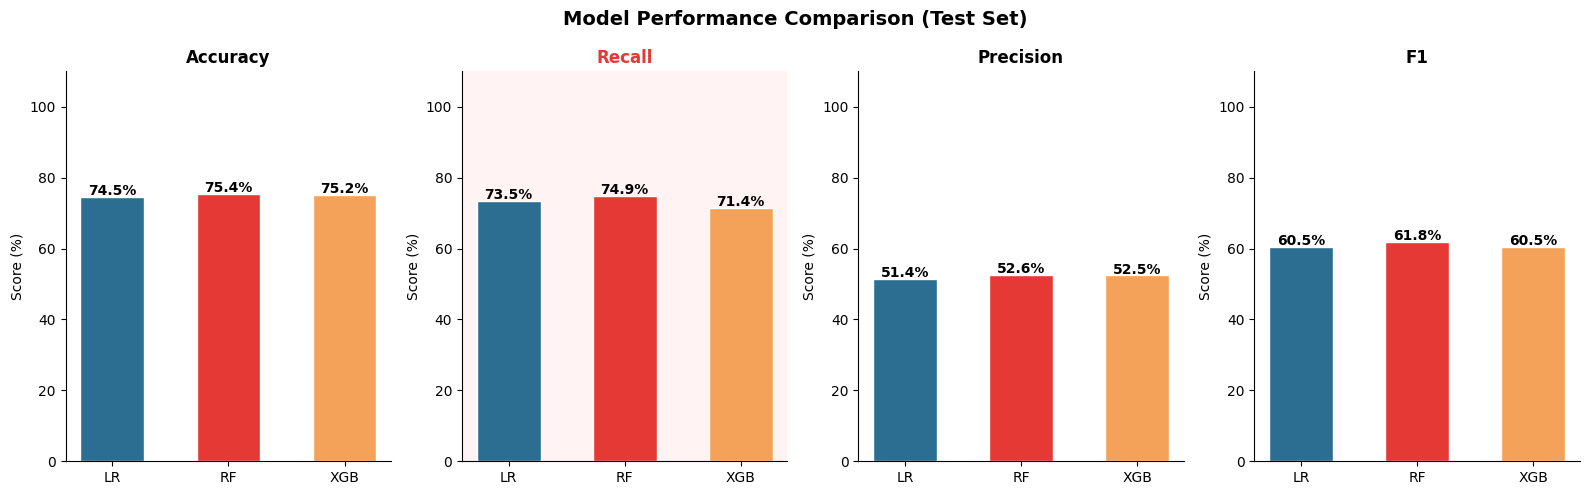

Chart saved: docs/charts/08_model_comparison.png


In [6]:
# Visual comparison
metrics    = ['Accuracy', 'Recall', 'Precision', 'F1']
bar_colors = [COLORS['no_churn'], COLORS['churn'], COLORS['neutral']]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Model Performance Comparison (Test Set)', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics):
    vals = results[metric] * 100
    bars = ax.bar(results['Model'], vals,
                  color=bar_colors, edgecolor='white', width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%',
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold',
                 color=COLORS['churn'] if metric == 'Recall' else 'black')
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 110)
    ax.set_xticklabels(['LR', 'RF', 'XGB'])
    ax.spines[['top','right']].set_visible(False)
    # Highlight Recall as our key metric
    if metric == 'Recall':
        ax.set_facecolor('#FFF3F3')

plt.tight_layout()
plt.savefig('../docs/charts/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: docs/charts/08_model_comparison.png')

## Save All Models


In [7]:
models = {
    'logistic_regression': {
        'model'     : lr_model,
        'pred'      : lr_pred,
        'pred_prob' : lr_pred_prob,
    },
    'random_forest': {
        'model'     : rf_model,
        'pred'      : rf_pred,
        'pred_prob' : rf_pred_prob,
    },
    'xgboost': {
        'model'     : xgb_model,
        'pred'      : xgb_pred,
        'pred_prob' : xgb_pred_prob,
    },
    'results_df'     : results,
    'feature_names'  : feature_names,
    'y_test'         : y_test,
    'X_test'         : X_test,
}

with open('../models/trained_models.pkl', 'wb') as f:
    pickle.dump(models, f)

print('All models saved to: models/trained_models.pkl')
print()


All models saved to: models/trained_models.pkl

